In [31]:
import random
import matplotlib.pyplot as plt
import numpy as np

# Парадокс не-транзитивных кубиков

Пусть даны 3 игральные кости: $A$, $B$ и $C$ с нестандартным количеством очков на каждой из 6 граней:  

$A: 2, 2, 4, 4, 9, 9$  
$B: 1, 1, 6, 6, 8, 8$  
$C: 3, 3, 5, 5, 7, 7$

Рассмотрим все варианты игры с двумя кубиками: $A$ и $B$, $B$ и $C$, $C$ и $A$.

Будем считать, что запись $A>B$ означает, что при одновременном броске кубиков $A$ и $B$ на кубике $A$ выпало большее число, то есть выиграл игрок с кубиком $A$.

При броске двух шестигранных кубиков каждый кубик может дать один из 6 результатов. Поэтому всего существует

$$
6 \cdot 6 = 36
$$

равновероятных пар результатов. Например, для кубиков $A$ и $B$ каждая пара $(a,b)$, где $a$ — результат броска кубика $A$, а $b$ — результат броска кубика $B$, является одним из 36 возможных исходов.


## 1. Игра с кубиками $A$ и $B$

Посчитаем количество случаев, в которых кубик $A$ выигрывает у кубика $B$, и количество случаев, в которых кубик $B$ выигрывает у кубика $A$.


In [3]:
A = [2, 2, 4, 4, 9, 9]
B = [1, 1, 6, 6, 8, 8]
A_win = 0
B_win = 0
for a in A:
    for b in B:
        if a > b:
            A_win += 1
        else:
            B_win += 1
print("Из 36 всевозможных исходов:")
print("Выигрышных у A -", A_win)
print("Выигрышных у B -", B_win)

Из 36 всевозможных исходов:
Выигрышных у A - 20
Выигрышных у B - 16


Следовательно:

$$
\mathrm{P}(A>B)=\frac{20}{36}=\frac{5}{9}\approx0.5556
$$

$$
\mathrm{P}(B>A)=\frac{16}{36}=\frac{4}{9}\approx0.4444
$$

Значит, кубик $A$ чаще выигрывает у кубика $B$.


## 2. Игра с кубиками $B$ и $C$

Посчитаем количество случаев, в которых кубик $B$ выигрывает у кубика $C$, и количество случаев, в которых кубик $C$ выигрывает у кубика $B$.


In [4]:
B = [1, 1, 6, 6, 8, 8]
C = [3, 3, 5, 5, 7, 7]
B_win = 0
C_win = 0
for b in B:
    for c in C:
        if b > c:
            B_win += 1
        else:
            C_win += 1
print("Из 36 всевозможных исходов:")
print("Выигрышных у B -", B_win)
print("Выигрышных у C -", C_win)

Из 36 всевозможных исходов:
Выигрышных у B - 20
Выигрышных у C - 16


Следовательно:

$$
\mathrm{P}(B>C)=\frac{20}{36}=\frac{5}{9}\approx0.5556
$$

$$
\mathrm{P}(C>B)=\frac{16}{36}=\frac{4}{9}\approx0.4444
$$

Значит, кубик $B$ чаще выигрывает у кубика $C$.


## 3. Игра с кубиками $C$ и $A$

На первый взгляд может показаться, что если кубик $A$ чаще выигрывает у кубика $B$, а кубик $B$ чаще выигрывает у кубика $C$, то кубик $A$ должен чаще выигрывать у кубика $C$. Проверим это.

Посчитаем количество случаев, в которых кубик $C$ выигрывает у кубика $A$, и количество случаев, в которых кубик $A$ выигрывает у кубика $C$.


In [5]:
C = [3, 3, 5, 5, 7, 7]
A = [2, 2, 4, 4, 9, 9]
C_win = 0
A_win = 0
for c in C:
    for a in A:
        if c > a:
            C_win += 1
        else:
            A_win += 1
print("Из 36 всевозможных исходов:")
print("Выигрышных у C -", C_win)
print("Выигрышных у A -", A_win)


Из 36 всевозможных исходов:
Выигрышных у C - 20
Выигрышных у A - 16


Следовательно:

$$
\mathrm{P}(C>A)=\frac{20}{36}=\frac{5}{9}\approx0.5556
$$

$$
\mathrm{P}(A>C)=\frac{16}{36}=\frac{4}{9}\approx0.4444
$$

Получается:

$$
A>B,\qquad B>C,\qquad C>A.
$$

То есть кубик $A$ чаще выигрывает у кубика $B$, кубик $B$ чаще выигрывает у кубика $C$, но при этом кубик $C$ чаще выигрывает у кубика $A$.

Такое отношение называется **нетранзитивным**. Оно кажется неожиданным, поскольку для обычного отношения превосходства ожидается транзитивность: если $A>B$ и $B>C$, то $A>C$. Для данных кубиков это свойство не выполняется. В этом и заключается парадокс нетранзитивных игральных костей.


## Моделирование

In [107]:
A = [2, 2, 4, 4, 9, 9]
B = [1, 1, 6, 6, 8, 8]
C = [3, 3, 5, 5, 7, 7]

counts = 1_000_000 + 1
counts_array = np.arange(1, counts)

def f(a, b, counts):
    win = {"a": 0,
        "b": 0}
    P_a = []
    P_b = []
    for i in range(1, counts):
        if random.choice(a) > random.choice(b):
            win["a"] += 1
        else:
            win["b"] += 1
        P_a.append(win["a"] / i)
        P_b.append(win["b"] / i)
    return P_a, P_b

P_A_1, P_B_1 = f(A, B, counts) 
P_B_2, P_C_2 = f(B, C, counts) 
P_C_3, P_A_3 = f(C, A, counts)

print(P_A_1[-1], P_B_1[-1])
print(P_B_2[-1], P_C_2[-1])
print(P_C_3[-1], P_A_3[-1])

0.555967 0.444033
0.555637 0.444363
0.554765 0.445235


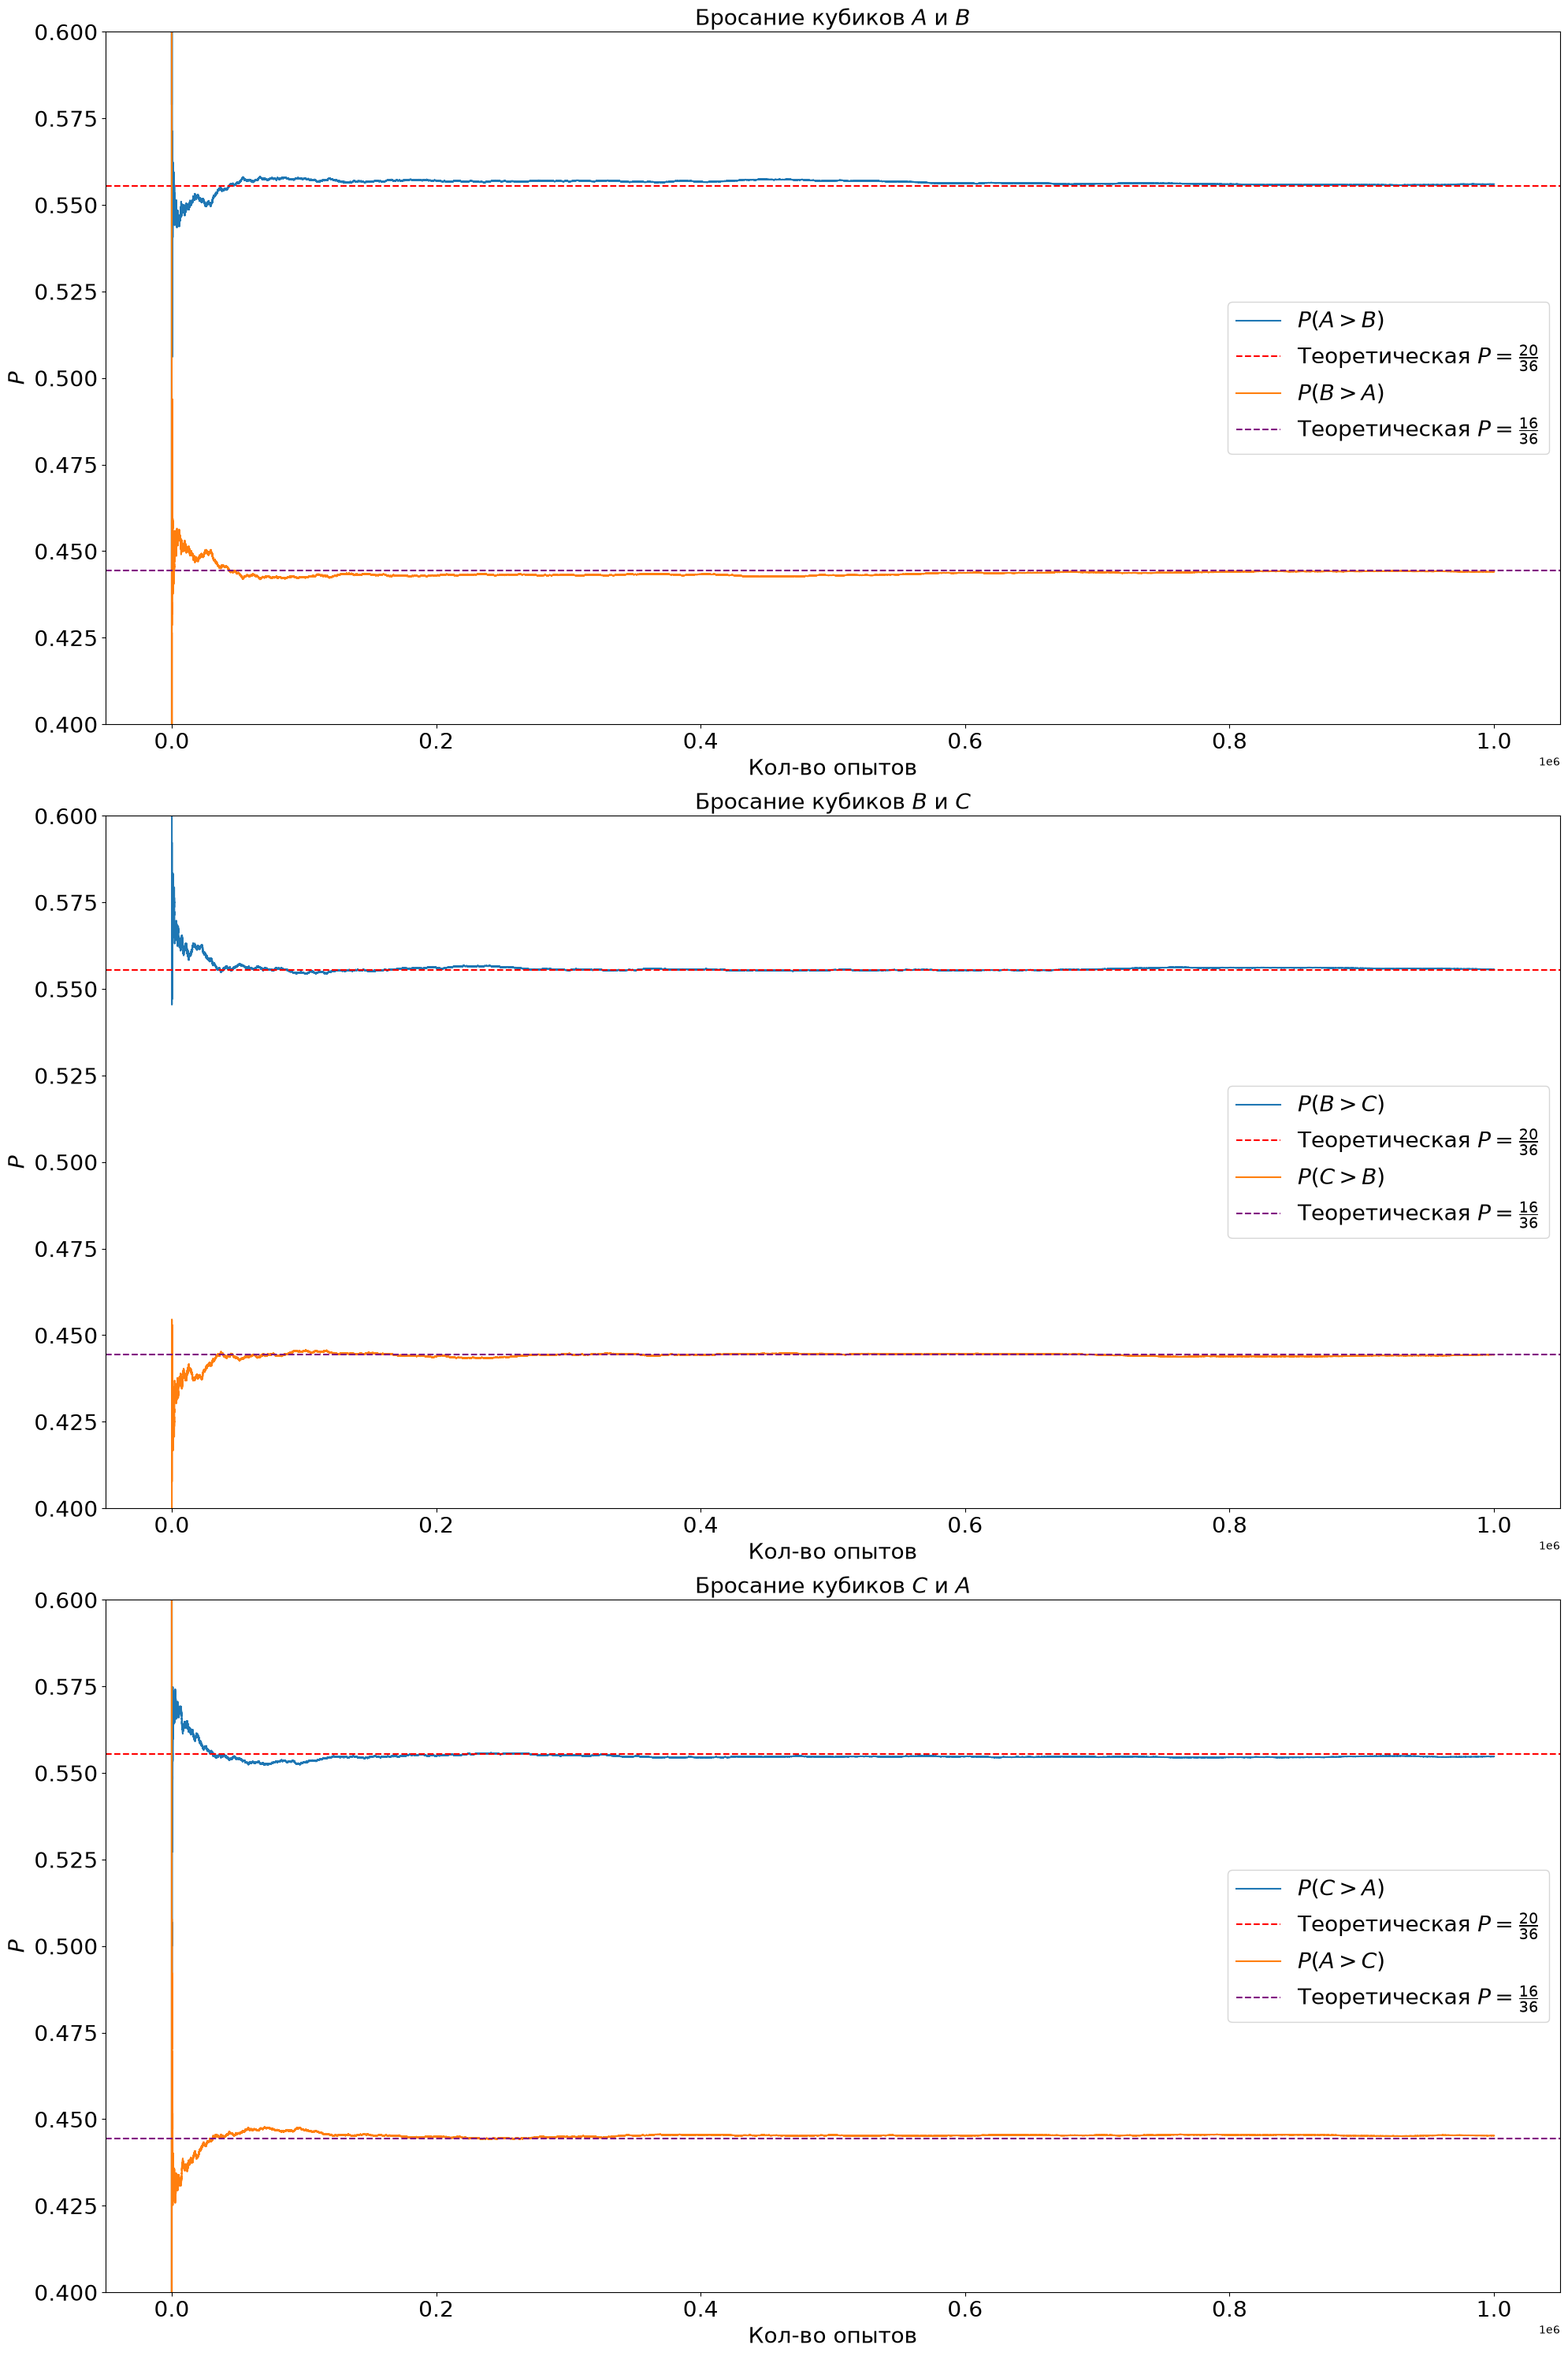

In [116]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(20, 30))

for ax, p, lbl, tlt in zip((ax1, ax2, ax3), 
                 ((P_A_1, P_B_1), 
                  (P_B_2, P_C_2), 
                  (P_C_3, P_A_3)), 
                    (("$P(A > B)$", "$P(B > A)$"), 
                     ("$P(B > C)$", "$P(C > B)$"), 
                     ("$P(C > A)$", "$P(A > C)$")), 
                        ("$A$ и $B$", "$B$ и $C$", "$C$ и $A$")):
    ax.set_ylim(0.4, 0.6)
    ax.set_ylabel("$P$", 
                  fontsize=20)
    ax.set_xlabel("Кол-во опытов", 
                  fontsize=20)
    ax.tick_params(axis="both", 
                   labelsize=20)

    ax.plot(counts_array, p[0], 
            label=lbl[0])
    ax.axhline(20/36, 
               color="red", 
               linestyle="--", 
               label=r"Теоретическая $P=\frac{20}{36}$")

    ax.plot(counts_array, p[1], label=lbl[1])
    ax.axhline(16/36, 
               color="purple", 
               linestyle="--", 
               label=r"Теоретическая $P=\frac{16}{36}$")

    ax.set_title(f"Бросание кубиков {tlt}", fontsize=20)
    ax.legend(fontsize=20)

plt.tight_layout()
plt.show()